# meridional heat transport data

In [1]:
import numpy as np
import xarray as xr
from glob import glob
import pandas as pd
from scipy import signal, stats
import os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

import palettable.colorbrewer as cb 
import cmocean as cmo
from statsmodels.tsa.stattools import ccf
from PIL import Image

from process_raw_data import process_data, decimal_year_to_datetime, plot_filter_response
from stats_plots import plot_timeseries, compute_n_eff_and_r_crit, plot_hovmöller, plot_crosscorr, plot_crosscorr_gif
from stats_plots import plot_all_leadlag, plot_max_lag, cross_block_coherence_index, block_mean_amplitude, block_leadlag, between_block_significance

In [2]:
SAVING = False 
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")

lats = ds.latitude.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]


region_labels = []

for i in range(len(lats) - 1):
    lat1 = lats[i]
    lat2 = lats[i + 1]

    def fmt(lat):
        if lat > 0:
            return f"{abs(int(lat))}°N"
        elif lat < 0:
            return f"{abs(int(lat))}°S"
        else:
            return "0°"

    region_labels.append(f"{fmt(lat1)}–{fmt(lat2)}")

print(region_labels)


['65°N–60°N', '60°N–55°N', '55°N–45°N', '45°N–35°N', '35°N–26°N', '26°N–16°N', '16°N–5°N', '5°N–5°S', '5°S–11°S', '11°S–25°S', '25°S–35°S']


## process the data 
# deseasonalize - detrend - low pass filter

only need to call the following once

In [3]:
ds["time"] = decimal_year_to_datetime(ds.time.values)


In [4]:
# ds = ds.rename({"number_regions": "lat"})


In [5]:
# heat transport

mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65
mht_mean = mht.mean(dim="posterior_samples")

# mht_filtered = process_data(mht_mean)
# for comparing
mht_filtered = process_data(mht_mean, method="tukey")

mht_detrended = process_data(mht_mean, detrended=True, restore_mean=True)
mht_detrended_anom = process_data(mht_mean, detrended=True).dropna(dim="time", how="any")

mht_3yr_filter = process_data(mht_mean, method="tukey", window=3 * 4)
# adapt lats to drop 65
lats = lats[1:]  # drop 65
lat_labels = lat_labels[1:]  # drop 65
n_lats = len(lats)

data_used = mht_detrended_anom

In [6]:

# plot_filter_response(cutoff=1/1, fs=4, order=4)


## colors for plotting

In [7]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 16,
    'ytick.labelsize' : 16,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})


def make_diverging_cmap(palette, n=40):
    if hasattr(palette, 'mpl_colors'):
        colors_ = palette.mpl_colors
        cmap = mcolors.LinearSegmentedColormap.from_list('custom_diverging', colors_)
    else:
        cmap = palette  # already a matplotlib Colormap (e.g. cmocean)
    return mcolors.ListedColormap(cmap(np.linspace(0, 1, n)))

cmap_corr = make_diverging_cmap(cb.diverging.RdBu_11_r)      # correlation: red-blue (conventional)
cmap_mht  = make_diverging_cmap(cb.diverging.PiYG_11_r)         # MHT anomalies
# cmap_mht = make_diverging_cmap(cmo.cm.curl)
cmap_hf   = make_diverging_cmap(cb.diverging.BrBG_11_r)         # HF anomalies


cmap_maxlag = make_diverging_cmap(plt.cm.PiYG_r,n = 23)


## before doing any kind of correlation - get N_eff for MHT 

In [8]:
time_unit = "years"  # or "months"
if time_unit == "months":
    del_t = 3
if time_unit == "years":
    del_t = 0.25
    

## now using mht mean (unprocessed) for significance!

In [9]:

n_effs_mht, r_crits_mht, its_mht = compute_n_eff_and_r_crit(
    data_used,
    coord_values=lats,
    coord_labels=lat_labels,
    dim="lat",
    del_t=del_t,
    time_unit=time_unit,
    # plateau_values=[45, 35],
    plot=False
)


# Hovmöller

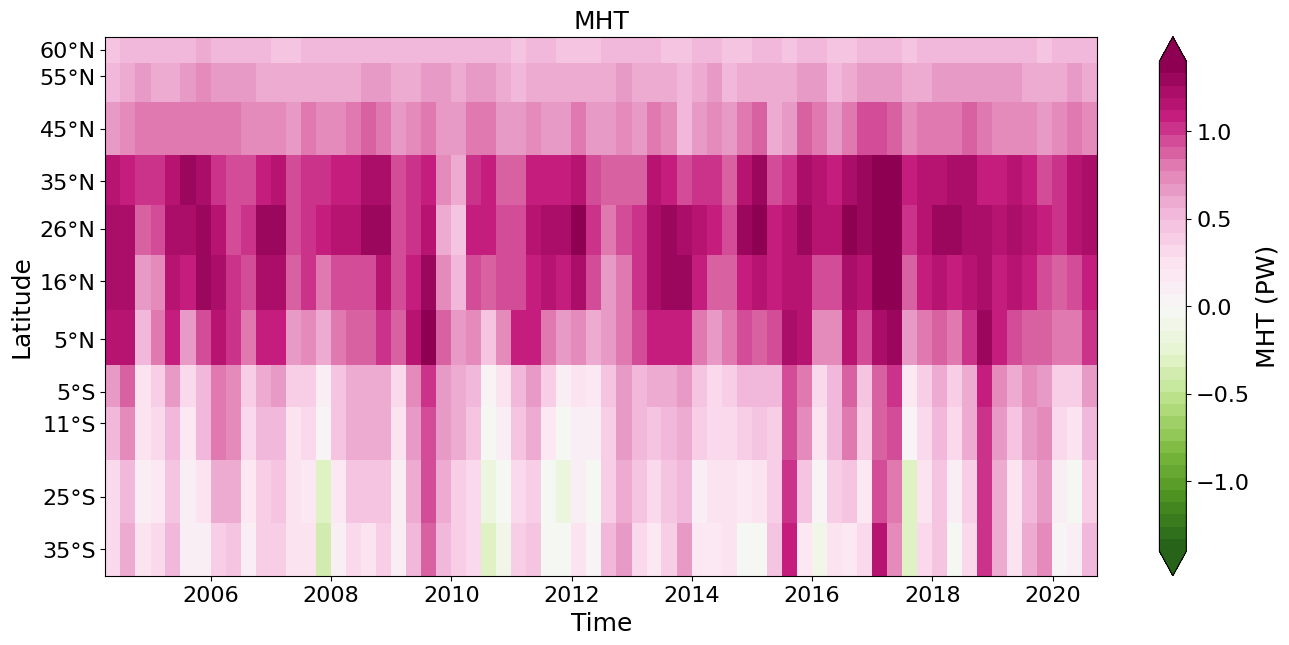

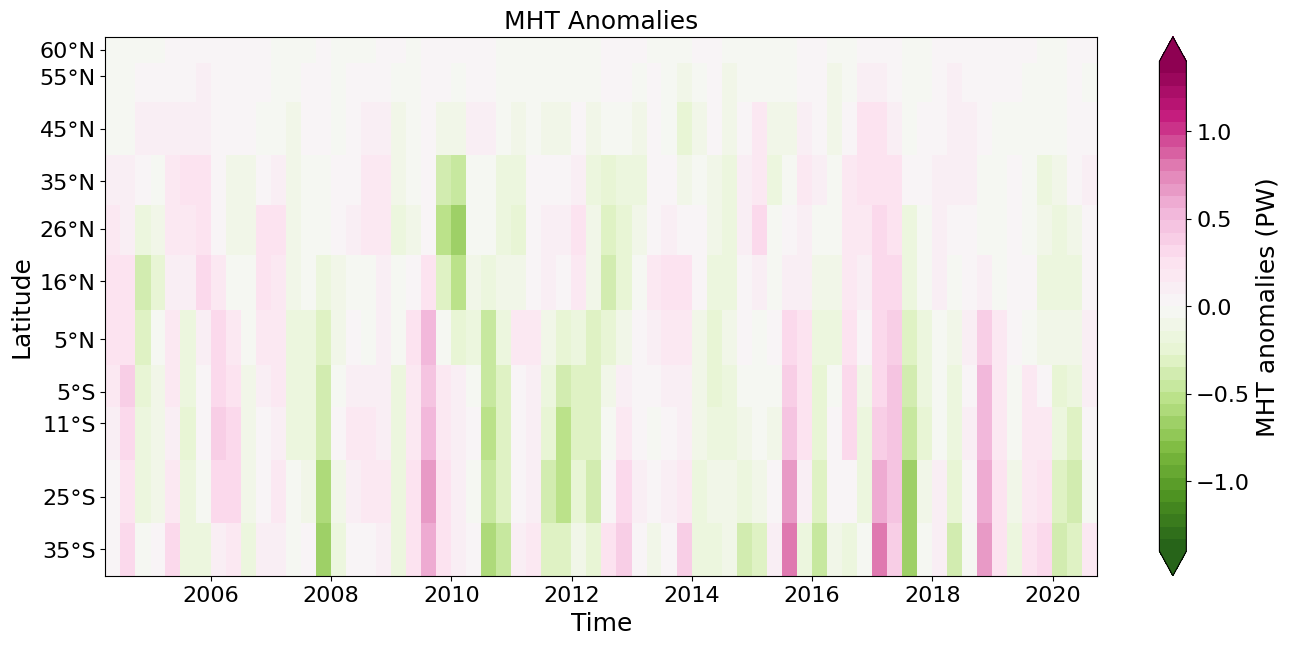

In [10]:
plot_hovmöller(
    mht_mean,
    lats=lats,
    lat_labels=lat_labels,
    anomalies=False,
    cmap=cmap_mht,
    vlimits=(-1.4, 1.4),
    savefig=SAVING
)
# plot_hovmöller(
#     mht_detrended,
#     lats=lats,
#     lat_labels=lat_labels,
#     anomalies=False,
#     cmap=cmap_mht,
#     vlimits=(-1.4, 1.4),
#     
# =False
# )

plot_hovmöller(
    data_used,
    lats=lats,
    lat_labels=lat_labels,
    anomalies=True,
    cmap=cmap_mht,
    savefig=SAVING,
    vlimits=(-1.4, 1.4)
)


## cross correlation
## split year, before and after 

In [11]:
lats

array([ 60.,  55.,  45.,  35.,  26.,  16.,   5.,  -5., -11., -25., -35.])

In [12]:
# lat_block = (-25, 26)
lat_block = (-35, 35)


lat_min, lat_max = lat_block
mask = (lats >= lat_min) & (lats <= lat_max)
lat_idx = np.where(mask)[0]



## periods from wavelet coherence

In [13]:
## from wavelet coherence, visible:
## break of coherence between 16°N and 5°N 
## between beginning of 2009 until end of 2014
periods = {
    "pre2009": ("2004", "2008-11"),
    "2009_2014": ("2009", "2014-11"),
    "post2014": ("2015", "2020"),
    "total": ("2004", "2020")
}

periods_labels = {
    "pre2009": "1. Pre 2009",
    "2009_2014": "2. 2009-2014",
    "post2014": "3. Post 2014",
    "total": "Total: 2004-2020"
}


## cross corr gif

In [14]:


# dates = []
# for year in range(2008, 2020):
#     for month in ["02", "05", "08", "11"]:
#         dates.append(f"{year}-{month}-01")

# min_samples = 8  # skip frames where prior/later would be too small to be meaningful
# frames = []

# for date in dates:
#     ds_prior = mht_filtered.sel(time=slice(None, date))
#     ds_later = mht_filtered.sel(time=slice(date, None))

#     if ds_prior.sizes["time"] < min_samples or ds_later.sizes["time"] < min_samples:
#         continue

#     fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#     plot_crosscorr_gif(ds_prior, lats, lat_labels, significance=True, n_effs=n_effs_mht,
#                    title=f"Prior to {date} (n={ds_prior.sizes['time']})",
#                    cmap=cmap_corr, ax=axes[0])
#     plot_crosscorr_gif(ds_later, lats, lat_labels, significance=True, n_effs=n_effs_mht,
#                    title=f"After {date} (n={ds_later.sizes['time']})",
#                    cmap=cmap_corr, ax=axes[1])

#     fig.suptitle(date)
#     fig.tight_layout()

#     buf = io.BytesIO()
#     fig.savefig(buf, format="png", dpi=100)
#     buf.seek(0)
#     frames.append(Image.open(buf).copy())
#     plt.close(fig)

# frames[0].save(
#     "figures/cross_corr/gif/crosscorr_evolution.gif",
#     save_all=True,
#     append_images=frames[1:],
#     duration=500,
#     loop=0
# )

## split cross corelation into 3 periods

In [15]:
# ### adjust the n effs right now, since it still doenst work fully
# keys_to_change = lats
# n_effs_changed = n_effs_mht

# for key in keys_to_change:
#     n_effs_changed[key] = np.float64(50.0)

In [16]:

# savename = "anomdetrended_data"

# data = mht_filtered
# savename = "tukeyfiltered_data"

# data = mht_detrended_anom
savename = "anomdetrended_data"


cmap_lats = cb.sequential.GnBu_9.mpl_colormap

lat_blocks = {
    "ST": (16, 35),
    "SA": (-35, 5),
    "coherence_block": (-35, 35)
}

# lat_blocks = {
#     "ST": (5, 35),
#     "SA": (-35, -5),
#     "coherence_block": (-35, 35)
# }
## mask for both blocks
mask = (
    ((lats >= lat_blocks["ST"][0]) & (lats <= lat_blocks["ST"][1])) |
    ((lats >= lat_blocks["SA"][0]) & (lats <= lat_blocks["SA"][1]))
)
lat_idx = np.where(mask)[0]
lats_slice = lats[lat_idx]


# separate blocks
lat_min, lat_max = lat_blocks["ST"]
lats_st = lats[(lats >= lat_min) & (lats <= lat_max)]
st_positions = [np.where(lats == l)[0][0] for l in lats_st]

lat_min, lat_max = lat_blocks["SA"]
lats_sa = lats[(lats >= lat_min) & (lats <= lat_max)]
sa_positions = [np.where(lats == l)[0][0] for l in lats_sa]


lat_min, lat_max = lat_blocks["ST"]
mask = (lats >= lat_min) & (lats <= lat_max)
lat_idx = np.where(mask)[0]
st_series = data_used.isel(lat=lat_idx).mean(dim="lat")   # full time range, no lat dim left

lat_min, lat_max = lat_blocks["SA"]
mask = (lats >= lat_min) & (lats <= lat_max)
lat_idx = np.where(mask)[0]
sa_series = data_used.isel(lat=lat_idx).mean(dim="lat")

## using the block mean for each block (so only time dim left)

sig_df = between_block_significance(
    st_series, sa_series,
    periods,          
    del_t=del_t,        # matching  compute_n_eff_and_r_crit 
    time_unit=time_unit, 
    plot=False,
    method="minimum",
)

print(sig_df)
# print(sig_df.loc["pre2009", "corr"])

               corr   n_eff_ST   n_eff_SA n_eff_used    r_crit significant
pre2009    0.527331  14.813842  16.747445  14.813842  0.517267        True
2009_2014 -0.022695  17.892835   6.741258   6.741258  0.768272       False
post2014   0.473598  17.126391  21.383476  17.126391  0.480326       False
total      0.295351  46.961608  52.940716  46.961608  0.287682        True


In [17]:
len(data_used.time.values)/4

16.5

In [18]:
signifance_periods = {}
for period_name, (year_start, year_end) in periods.items():
    # print(period_name)
    data_period = data_used.sel(time=slice(year_start, year_end))
    print("length of period: ", len(data_period.time.values)/4)
    print(data_period.time.values[0])
    print(data_period.time.values[-1])
    signifance_periods[period_name] = {}
    
    plotting = False
    printing = False
    # if period_name == "2009_2013":
        # plotting = True
        # printing = True
        
    n_eff_period, r_crit_period, its_period = compute_n_eff_and_r_crit(
        data_period,
        lats,
        lat_labels,
        dim="lat",
        del_t=del_t,
        time_unit=time_unit,
        printout=printing,
        plot=plotting,
        method="minimum",
    )
    
    signifance_periods[period_name]["n_eff"] = n_eff_period
    signifance_periods[period_name]["r_crit"] = r_crit_period
    signifance_periods[period_name]["its"] = its_period

# signifance_periods["pre2009"]["n_eff"]

length of period:  4.75
2004-05-15T23:59:59.999997
2008-11-14T23:59:59.999997
length of period:  6.0
2009-02-14T00:00:00.000002
2014-11-15T00:00:00.000001
length of period:  5.75
2015-02-14T00:00:00.000002
2020-08-14T23:59:59.999998
length of period:  16.5
2004-05-15T23:59:59.999997
2020-08-14T23:59:59.999998


In [19]:
idx_26 = [np.where((lats == 26))[0][0]]
idx_11S = [np.where((lats == -11))[0][0]]

idx_5 = [np.where((lats == 5))[0][0]]
# idx_5S = [np.where((lats == -5))[0][0]]
idx_16 = [np.where((lats == 16))[0][0]]



Period: pre2009, years: 2004-2008-11, samples: 19
Period: 2009_2014, years: 2009-2014-11, samples: 24
Period: post2014, years: 2015-2020, samples: 23
          corr_26_11S significance_mask_26_11S: corr_5_16  \
pre2009      0.414514                     False  0.818963   
2009_2014   -0.281884                     False  0.600778   
post2014      0.45376                      True  0.820105   

          significance_mask_5_16:  
pre2009                      True  
2009_2014                   False  
post2014                     True  


/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_3359/4052787454.py:64: RuntimeWarning: Mean of empty slice
  mean_coh = cross_sub[mask_sub].mean() # if n_valid >= 2 else np.nan
/Users/leadietz/Desktop/uni/masterthesis/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_3359/4052787454.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


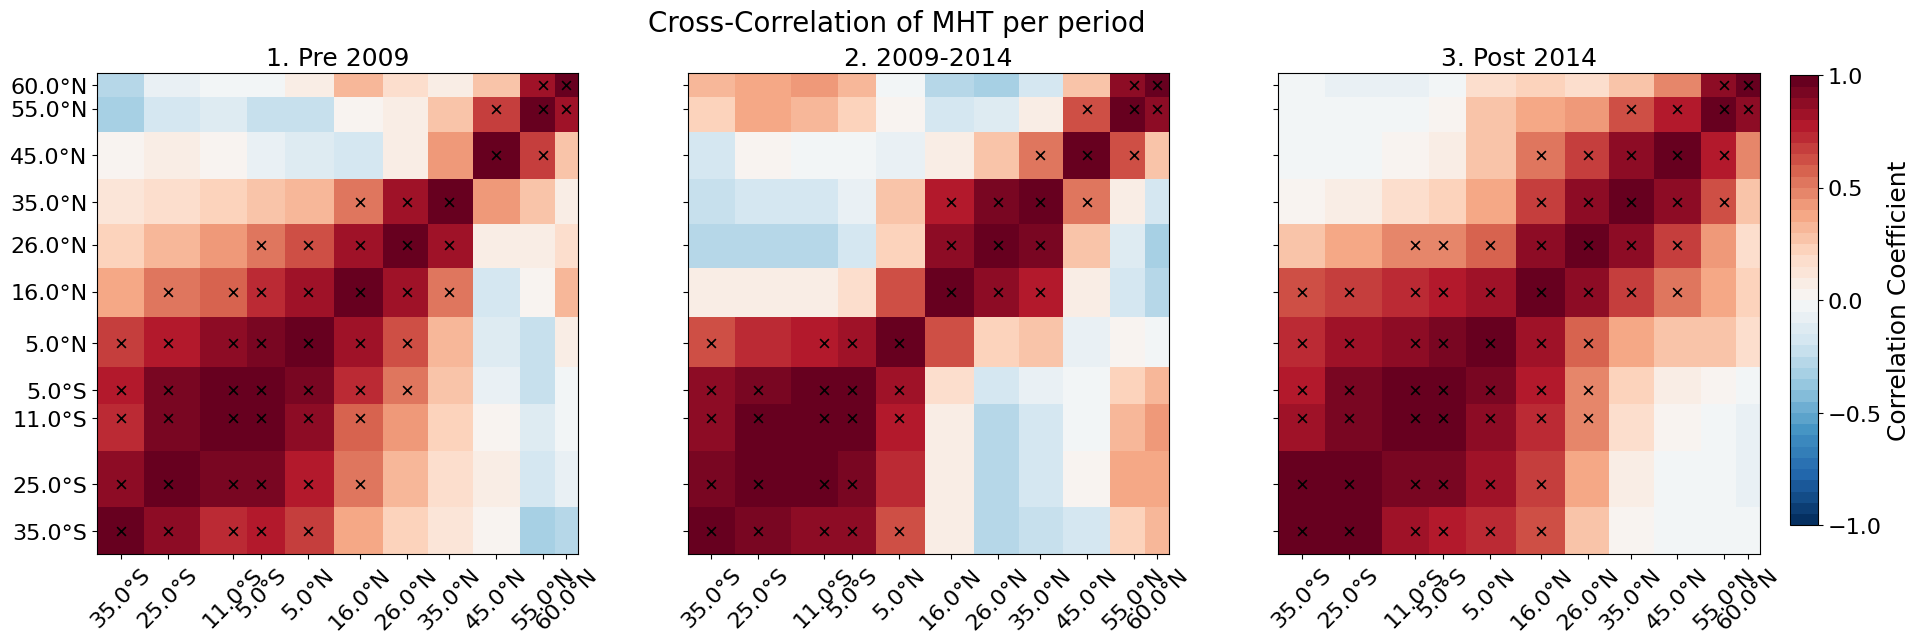

In [20]:

periods_corrs = {}
periods_significance = {}
cross_block_results = {}

only_total = {k: v for k, v in periods.items() if k == "total"}

sub_periods = {k: v for k, v in periods.items() if k != "total"}

total = False 
if total == True:
    periods_sel = only_total
    n = len(only_total)
else: 
    periods_sel = sub_periods
    n = len(sub_periods)

fig, axes = plt.subplots(1, len(periods_sel), figsize=(6.2 * n, 6), sharey=True)

if n == 1:
    axes = [axes]
    
fig.subplots_adjust(right=0.85)  # leave some space for the colorbar on the right....
cbar_ax = fig.add_axes([0.98, 0.15, 0.015, 0.75])  # [left, bottom, width, height]

# for period_name, (year_start, year_end) in periods.items():
for i, (ax, (period_name, (t0, t1))) in enumerate(zip(axes, periods_sel.items())):
    data_period = data_used.sel(time=slice(t0, t1))
    print(f"Period: {period_name}, years: {t0}-{t1}, samples: {data_period.sizes['time']}")

    # print("start of this period: ", data_period.time.values[0])
    # print("end of this period: ", data_period.time.values[-1])
    n_effs_period = signifance_periods[period_name]["n_eff"]
    r_crits_period = signifance_periods[period_name]["r_crit"]
    
    corr_matrix, significance_mask, cf = plot_crosscorr(
        data_period,
        lats=lats,
        lat_labels=lat_labels,
        cmap=cmap_corr,
        significance=True,
        n_effs=n_effs_period, 
        r_crits=r_crits_period,
        subtitle=f"{periods_labels[period_name]}",
        # savefig=True,
        # savename=f"crosscorr_{period_name}",
        ax=ax,
        show_cbar=False, # only last i has colorbar, or No one 
        # savename=f"crosscorr_mht_{period_name}"
    )    
    periods_corrs[period_name] = corr_matrix
    periods_significance[period_name] = significance_mask
    # extract ST x SA cross-block sub-matrix straight from this period's matrix/mask
    cross_sub = corr_matrix[np.ix_(st_positions, sa_positions)]
    corr_26_11S = corr_matrix[np.ix_(idx_26, idx_11S)]
    sign_26_11S  = significance_mask[np.ix_(idx_26, idx_11S)]
    corr_5_16 = corr_matrix[np.ix_(idx_5, idx_16)]
    sign_5_16  = significance_mask[np.ix_(idx_5, idx_16)]

    # print(corr_26_11)
    mask_sub = significance_mask[np.ix_(st_positions, sa_positions)]

    n_valid = int(mask_sub.sum())
    n_total = cross_sub.size
    mean_coh = cross_sub[mask_sub].mean() # if n_valid >= 2 else np.nan
    mean_corr = cross_sub.mean()
    

    cross_block_results[period_name] = {
        # "mean_cross_coherence": mean_coh,
        # "mean_corr": mean_corr,
        # "n_valid_pairs": n_valid,
        # "n_total_pairs": n_total,
        "corr_26_11S": corr_26_11S[0][0],
        "significance_mask_26_11S:": sign_26_11S[0][0],
        "corr_5_16": corr_5_16[0][0],
        "significance_mask_5_16:": sign_5_16[0][0],
        
    }
  

cbar = fig.colorbar(cf, cax=cbar_ax, label='Correlation Coefficient')
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

fig.suptitle(f"Cross-Correlation of MHT per period", y=1.01)
plt.tight_layout()
if SAVING:
    plt.savefig(f"figures/cross_corr/crosscorr_{savename}", dpi=300, bbox_inches='tight')
    
      
      
    # print(corr_matrix)xw
cross_block_df = pd.DataFrame(cross_block_results).T
print(cross_block_df)


## timeseries

In [21]:

# for period_name, (t0, t1) in periods.items():
#     data_period = mht_filtered.sel(time=slice(t0, t1))  

#     fig, ax = plot_timeseries(
#         data=data_period,
#         lats=lats_slice,        
#         all_lats=lats,          
#         labels=lat_labels,      
#         title="MHT anomaly",
#         savefig=True,
#         savelabel=f"mht",
#         label=f"{t0}-{t1}",
#         grid=True,
#         loc_legend=None,
#         ylim=(-0.55, 0.55),
#         cmap=cmap_lats
#     )
#     plt.show()

## timeseries of block means

In [22]:


def crop_cmap(cmap, lo=0.3, hi=1.0, n=256):
    if hasattr(cmap, "mpl_colormap"):   # handles palettable objects too
        cmap = cmap.mpl_colormap
    colors = cmap(np.linspace(lo, hi, n))
    return mcolors.LinearSegmentedColormap.from_list(f"{getattr(cmap,'name','cmap')}_cropped", colors)

# cmap_cropped_lats = crop_cmap(cb.sequential.GnBu_9, lo=0.4, hi=0.8)
# cmap_cropped_lats = crop_cmap(plt.cm.cividis, lo=0.1, hi=0.5)
cmap_cropped_lats = crop_cmap(plt.cm.Greys_r, lo=0.1, hi=0.5)

for period_name, (t0, t1) in periods.items():
    period_data = data_used.sel(time=slice(t0, t1))

    lat_min, lat_max = lat_blocks["ST"]
    mask = (lats >= lat_min) & (lats <= lat_max)
    lat_idx = np.where(mask)[0]
    st_mean = period_data.isel(lat=lat_idx).mean(dim="lat").expand_dims({"lat": [0]})

    lat_min, lat_max = lat_blocks["SA"]
    mask = (lats >= lat_min) & (lats <= lat_max)
    lat_idx = np.where(mask)[0]
    sa_mean = period_data.isel(lat=lat_idx).mean(dim="lat").expand_dims({"lat": [0]})

    data_blocks = {
        "35-16°N (ST)": st_mean,
        "5°N-35°S (SA)": sa_mean,
    }
    
    

    # fig, ax = plot_timeseries(
    #     data=data_blocks,
    #     lats=[0],
    #     all_lats=[0],
    #     labels=["block mean"],
    #     title="MHT block-mean anomaly",
    #     cmap=cmap_cropped_lats,
    #     label=f"{t0}-{t1}",
    #     savefig=True,
    #     savelabel="MHT_blockmeans",
    #     grid=True,
    #     ylim=(-0.55, 0.55)
    # )
    # plt.show()

## plot for 26°N and 25°S

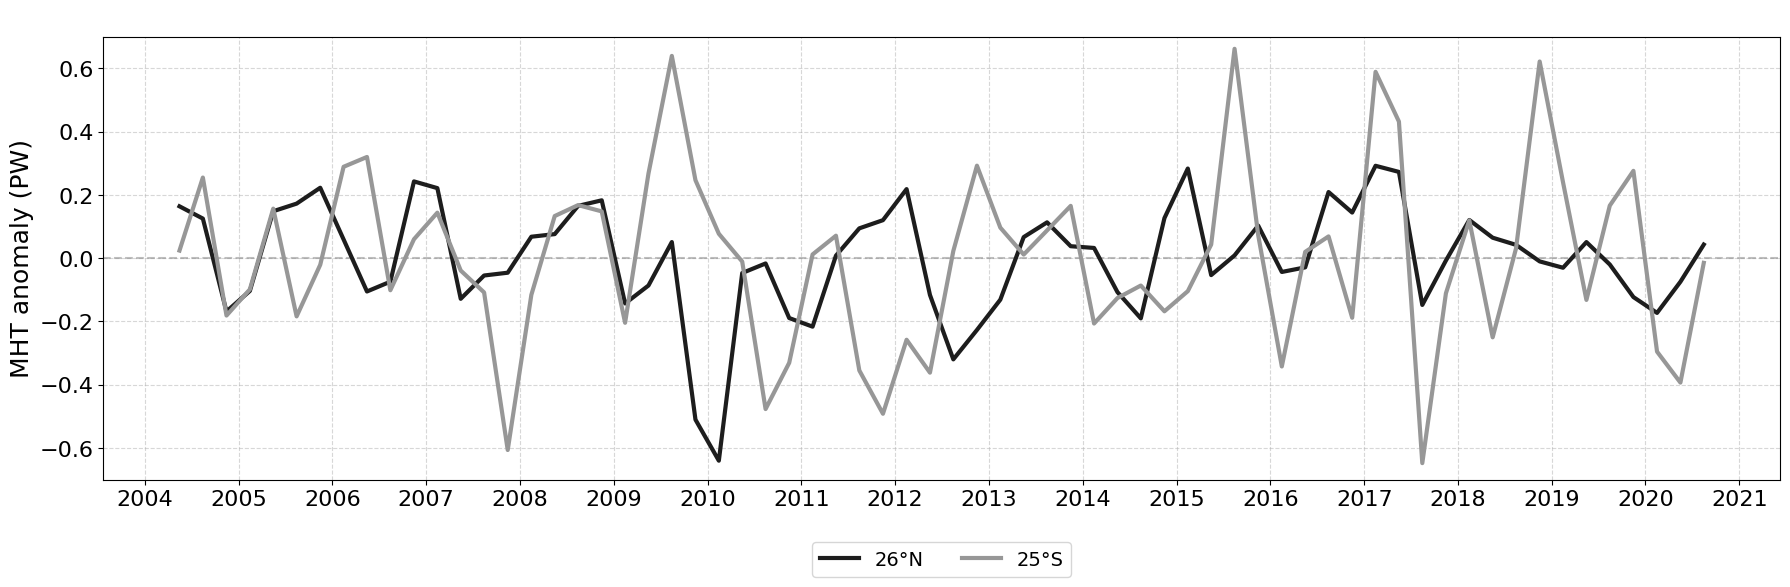

In [23]:

# for period_name, (t0, t1) in periods.items():
#     period_data = data_used.sel(time=slice(t0, t1))

idx_26 = [np.where((lats == 26))[0][0]]
period_26N = data_used.isel(lat=idx_26)

idx_25S = [np.where((lats == -25))[0][0]]
period_25S = data_used.isel(lat=idx_25S)
fig, ax = plot_timeseries(
data={"26°N" : period_26N,
      "25°S": period_25S},
lats=[0],
all_lats=[0],
labels=["26°N", "25°S"],
title="",
cmap=cmap_cropped_lats,
label=f"",
savefig=True,
savelabel=f"MHT_26N25S_total",
grid=True,
linestyles={"26°N" : "-",
      "25°S": "-"},
ylim=(-0.7, 0.7)
)
    # plt.show()

## plot for 16°N and 5°S

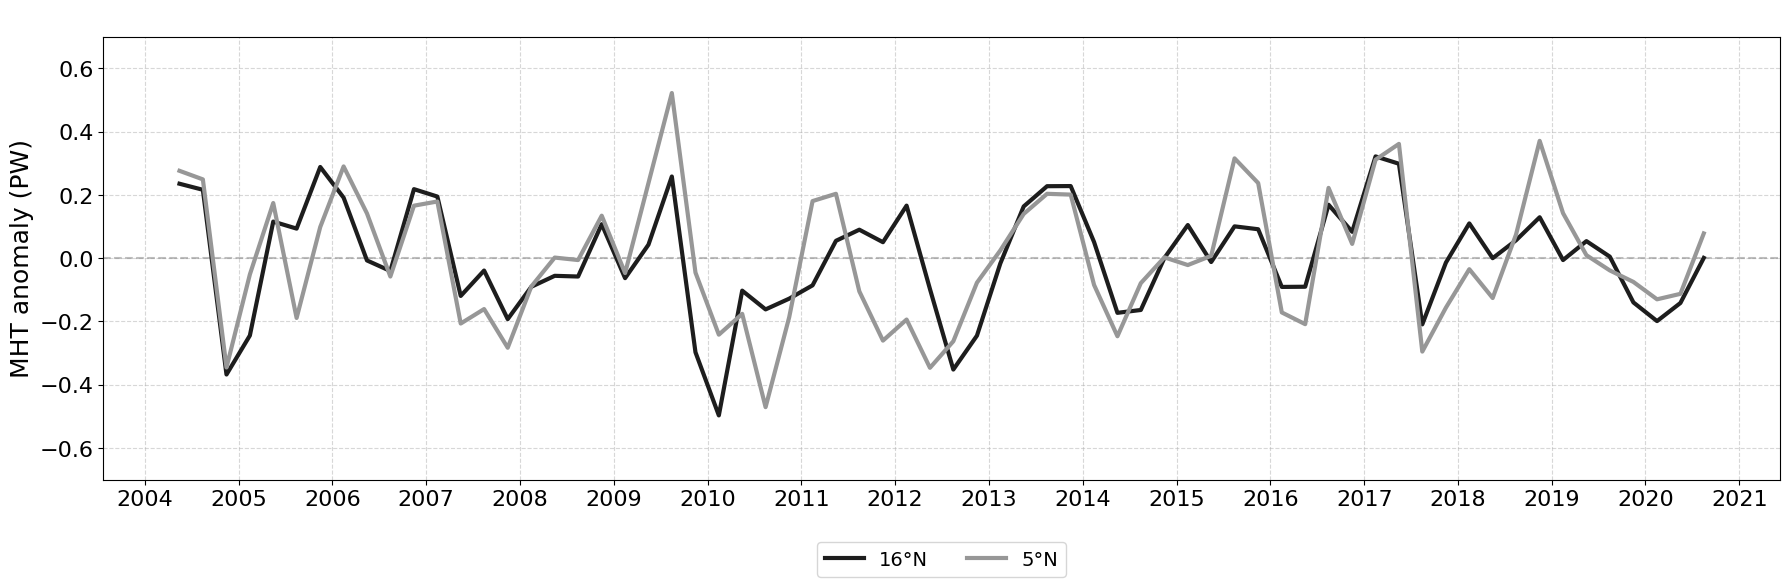

In [24]:

# for period_name, (t0, t1) in periods.items():
#     period_data = data_used.sel(time=slice(t0, t1))

idx_16 = [np.where((lats == 16))[0][0]]
period_16 = data_used.isel(lat=idx_16)

idx_5 = [np.where((lats == 5))[0][0]]
period_5 = data_used.isel(lat=idx_5)
fig, ax = plot_timeseries(
data={"16°N" : period_16,
      "5°N": period_5},
lats=[0],
all_lats=[0],
labels=["16°N", "5°N"],
title="",
cmap=cmap_cropped_lats,
label=f"",
savefig=True,
savelabel=f"MHT_16N5N_total",
grid=True,
linestyles={"16°N" : "-",
      "5°N": "-"},
ylim=(-0.7, 0.7)
)
    # plt.show()

# check the z score between all for the 3 different timeperiods

In [25]:
# mht_zscore = (mht_filtered - mht_filtered.mean(dim="time")) / mht_filtered.std(dim="time", ddof=1)

## pairwise RMSE and correlation

## check pairwise correlation

# between blocks ST and SA

i dont do this anymore, as we discussed with eleanor that calcualting the significance like will never yield correlation high enough to be significance ( neff always too small for this short period) 
alwaays use the once pre calcuated neff to get r crit each time. 
cross check with the raw data if i still find the same or similar behavoir to check significance, or that we trust it


In [26]:
# summary = block_coherence_index(mht_filtered, r_crits_mht, lat_idx, lats, periods)
# print(summary)


## WITH THIS new n_eff for each period, do the cross correlation plot again with the correct significant markers!



In [27]:

# only_total = {k: v for k, v in periods.items() if k == "total"}

# sub_periods = {k: v for k, v in periods.items() if k != "total"}

# total = False 
# if total == True:
#     periods_sel = only_total
#     n = len(only_total)
# else: 
#     periods_sel = sub_periods
#     n = len(sub_periods)

# indiv_periods_significance = {}

# fig, axes = plt.subplots(1, len(periods_sel), figsize=(6.5 * n, 6), sharey=True)

# if n == 1:
#     axes = [axes]
    
# fig.subplots_adjust(right=0.9)  # leave some space for the colorbar on the right....
# cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]

# for i, (ax, (period_name, (t0, t1))) in enumerate(zip(axes, periods_sel.items())):
#     # period_data = mht_filtered_tukey.sel(time=slice(t0, t1))
#     period_data = mht_filtered.sel(time=slice(t0, t1))

#     print(f"Period: {period_name} ({t0}-{t1}), samples: {period_data.sizes['time']}")

#     ## get n eff etc for that period alone        
#     n_eff_period, r_crit_period, its_mht_period = compute_n_eff_and_r_crit(
#         period_data,
#         coord_values=lats,
#         coord_labels=lat_labels,
#         dim="lat",
#         del_t=del_t,
#         time_unit=time_unit,
#         plot=False
#     )
#     ## save the results
#     indiv_periods_significance[period_name] = {
#         "n_eff" : n_eff_period,
#         "r_crit": r_crit_period,
#         "its" : its_mht_period
#     }
#     ## plot cross correlation using neff for each period
    
#     corr_matrix, significance_mask, cf = plot_crosscorr(
#         period_data,
#         lats=lats,
#         lat_labels=lat_labels,
#         cmap=cmap_corr,
#         significance=True,
#         n_effs=n_eff_period,
#         subtitle=f"{period_name.replace("_", " ")}",
#         # savefig=True,
#         # savename=f"crosscorr_{period_name}",
#         ax=ax,
#         show_cbar=False # only last i has colorbar, or No one 
#         # savename=f"crosscorr_mht_{period_name}"
#     )

# cb = fig.colorbar(cf, cax=cbar_ax, label='Correlation Coefficient')
# cb.set_ticks([-1, -0.5, 0, 0.5, 1])

# fig.suptitle("Cross-Correlation of MHT anomalies per period")
# plt.tight_layout()
# plt.savefig("figures/cross_corr/crosscorr_all", dpi=300, bbox_inches='tight')
    

## time mean - fig. 7 calafat

In [28]:
sub_periods = {k: v for k, v in periods.items() if k != "total"}

period_means = {}

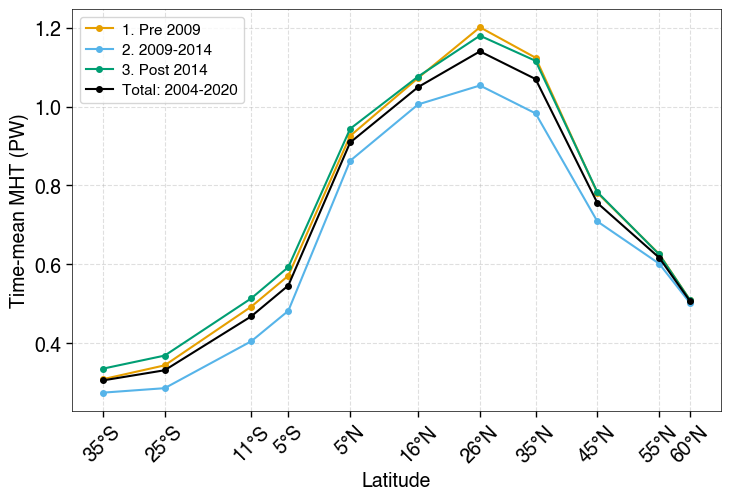

In [50]:
SAVING = True
fig, ax = plt.subplots(figsize=(7.5, 5.2))

plt.rcParams.update({
    "font.family":  "Helvetica",   
    "font.size":    13,
    # axes
    # 'axes.titlesize'  : 14,
    # 'axes.labelsize'  : 14,
    # # ticks
    # 'xtick.labelsize' : 14,
    # 'ytick.labelsize' : 14,
    # # legend
    # 'legend.fontsize' : 16,
    # 'legend.title_fontsize': 16,
    # # colorbar
    # 'figure.titlesize': 20,
})
fontsize = 14


n_periods = len(periods.keys())
# cmap_sel = plt.cm.tab20b
# cmap = mcolors.ListedColormap(cmap_sel(np.linspace(0, 0.8, 4)))
# colors = [cmap(i / max(n_periods - 1, 1)) for i in range(n_periods)]
# colors = ["purple", "rebeccapurple", "plum", "black"]
# colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]
colors = ["#E69F00", "#56B4E9", "#009E73", "black"]
alphas = [1, 1, 1, 1]
ax.spines["left"].set_linewidth(0.5)
ax.spines["right"].set_linewidth(0.5)
ax.spines["top"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

### CALAFAT data with error bars
# mht_ci.mean(dim="TIME")

for idx, (period_name, (year_start, year_end)) in enumerate(periods.items()):
    # print(period_name)
    data_period = mht_detrended.sel(time=slice(year_start, year_end)).mean(dim="time")
    period_means[period_name] = data_period

    ax.plot(lats, 
            data_period,
            label=periods_labels[period_name],
            color=colors[idx],
            alpha=alphas[idx],
            # linewidth=1.5,
            linestyle="-",
            marker=".",
            markersize=8, 
    )
              
# ax.errorbar(
#     lats, mht_all_mean,
#     yerr=mht_ci.mean(axis=2), # axis 2 is the time dim, 1 is lat and 0 is upper lower
#     fmt="o",
#     color="#C0392B",
#     markerfacecolor="#C0392B",
#     markersize=6,
#     ecolor="#C0392B",
#     elinewidth=1.2,
#     capsize=3,
#     capthick=1.2,
#     zorder=4,
#     label="BHM (2004–2020)",
# )

ax.set_ylabel("Time-mean MHT (PW)", fontsize=fontsize)
ax.set_xlabel("Latitude", fontsize=fontsize)
# ax.set_ylim(0.0, None)
ax.set_xlim(-40, 65)

xtick_pos    = [-35, -25, -11, -5,  5,  16, 26, 35, 45, 55, 60]
xtick_labels = [i.replace(".0", "") for i in lat_labels[::-1]]
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, fontsize=fontsize, rotation=45)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis="both", which="major", length=4, width=1.0)

legend = ax.legend(
    loc="upper left",
    frameon=True,         
    fontsize=11,
    handlelength=1.8,
    handletextpad=0.6,
    labelspacing=0.4,
)
plt.grid(alpha=0.4, linestyle="--")
plt.tight_layout()
if SAVING:
    os.makedirs("figures/fig8/", exist_ok=True)
    plt.savefig("figures/fig8/3periods_total.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
# time mean period data stacked: 
stacked = xr.concat(period_means.values(), dim=pd.Index(period_means.keys(), name="period"))

# max difference across periods, per lat
max_diff = stacked.max(dim="period") - stacked.min(dim="period")
argmax_period = stacked.argmax(dim="period")  # index into period dim
argmin_period = stacked.argmin(dim="period")

period_names_arr = np.array(list(period_means.keys()))
max_period_per_lat = period_names_arr[argmax_period.values]
min_period_per_lat = period_names_arr[argmin_period.values]

diff_df = pd.DataFrame({
    "lat": lat_labels,
    "max_diff": max_diff.values,
    "period_max": max_period_per_lat,
    "period_min": min_period_per_lat,
})

In [31]:
diff_df

,lat,max_diff,period_max,period_min
0,60.0°N,0.007604,pre2009,2009_2014
1,55.0°N,0.024540,pre2009,2009_2014
2,45.0°N,0.074359,post2014,2009_2014
3,35.0°N,0.141260,pre2009,2009_2014
4,26.0°N,0.147777,pre2009,2009_2014
5,16.0°N,0.070782,post2014,2009_2014
6,5.0°N,0.081207,post2014,2009_2014
7,5.0°S,0.110903,post2014,2009_2014
8,11.0°S,0.108909,post2014,2009_2014
9,25.0°S,0.082735,post2014,2009_2014


In [32]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 20,
    'axes.labelsize'  : 20,
    # ticks
    'xtick.labelsize' : 18,
    'ytick.labelsize' : 18,
    
    # legend
    'legend.fontsize' : 18,
    'legend.title_fontsize': 18,
    # colorbar
    'figure.titlesize': 22,
})



## ideas to quantify coherence break with heat and timescales

## maybe calculate an annual mean of MHT inside the block, for boths smaller blocks for the 3 periods
## and plot timeseries of it or so? 
## also not anomalies but values of MHT  ? 

In [33]:
mht_mean_filtered = process_data(mht_mean, restore_mean=True)

lat_idx_st = np.where((lats >= lat_blocks["ST"][0]) & (lats <= lat_blocks["ST"][1]))[0]
lat_idx_sa = np.where((lats >= lat_blocks["SA"][0]) & (lats <= lat_blocks["SA"][1]))[0]


st_data = mht_filtered.isel(lat=lat_idx_st)#.mean(dim="lat")
sa_data = mht_filtered.isel(lat=lat_idx_sa)#.mean(dim="lat")

blocks_dict = {
    "ST": st_data,
    "SA": sa_data
}

In [34]:

##################
#  1. AMPLITUDE  #
##################

def block_amplitude(blocks_dict, periods):
    """
    calculated the amplitude (std and peak-to-peak) of the time series for each block and period.
    Amplitude is temporal STD of block
    series_dict: {'ST': st_series, 'SA': sa_series}
    """
    rows = {}
    for block_name, block_data in blocks_dict.items():
        block_mean = block_data.mean(dim="lat")
        # block is ST and SA
        for period_name, (t0, t1) in periods.items():
            s = block_mean.sel(time=slice(t0, t1))
            
            rows[(block_name, period_name)] = {
                "std": float(s.std(dim="time")),
                "peak_to_peak": float(s.max() - s.min()),
            }
    return pd.DataFrame(rows).T

amp_df = block_amplitude(blocks_dict, periods)
# print("Amplitu#de DataFrame:\n", amp_df)
# print("SA/ST amplitude ratio:\n", amp_df.xs("SA", level=0)["std"] / amp_df.xs("ST", level=0)["std"])

##################
#  2. spatial spread #
##################

def spatial_spread(blocks_dict, periods):
    """
     latitudinal STD over block, averaged over time for each period.
    """
    rows = {}
    for block_name, block_data in blocks_dict.items():        
        for period_name, (t0, t1) in periods.items():
            s = block_data.sel(time=slice(t0, t1)).std(dim="lat").mean()
            rows[(block_name, period_name)] = float(s)
    return pd.Series(rows)

spread = spatial_spread(blocks_dict, periods)
print("spatial spread:\n", spread)

##########################################
#  spread across both blocks combined    #
##########################################

lat_idx_across = np.where(
    ((lats >= lat_blocks["ST"][0]) & (lats <= lat_blocks["ST"][1])) |
    ((lats >= lat_blocks["SA"][0]) & (lats <= lat_blocks["SA"][1]))
)[0]

across_data = mht_filtered.isel(lat=lat_idx_across)

def spread_across_blocks(block_data, periods):
    """
    Latitudinal STD pooling both ST and SA latitudes together,
    averaged over time for each period. Answers: how spread out
    is the anomaly across the whole ST+SA latitude range, treating
    it as one combined set of latitudes (not two separate blocks).
    """
    rows = {}
    for period_name, (t0, t1) in periods.items():
        s = block_data.sel(time=slice(t0, t1)).std(dim="lat").mean()
        rows[period_name] = float(s)
    return pd.Series(rows)

across_spread = spread_across_blocks(across_data, periods)
print("spread across both blocks combined:\n", across_spread)

# avg_individual = (spread["ST"] + spread["SA"]) / 2 # average across spead 
# excess_spread = across_spread - avg_individual

# print("average individual spread:\n", avg_individual)
# print("excess spread (across - average individual):\n", excess_spread)

spatial spread:
 ST  pre2009      0.052720
    2009_2014    0.043728
    post2014     0.031759
    total        0.041975
SA  pre2009      0.055051
    2009_2014    0.065402
    post2014     0.071008
    total        0.064566
dtype: float64
spread across both blocks combined:
 pre2009      0.081665
2009_2014    0.120339
post2014     0.102968
total        0.103837
dtype: float64


In [35]:
# lat_sel = 26
# fig, ax = plot_timeseries(
#     data={
#         "mean filtered": mht_mean_filtered,
#         "anomalies filtered": mht_filtered,
#         "raw": mht_mean,
#     },
#     lats=[lat_sel],          # single latitude, still needs to be a list/array
#     all_lats=lats,    # same full lat list you always pass, for color lookup
#     labels=lat_labels,
#     title="MHT",
#     label=f"{lat_sel}°N",
#     anomalies=False,
#     cmap=plt.cm.Dark2,
# )

In [36]:
# for lat in lats:
#     print(lat, r_crits_mht[lat], critical_r(n_effs_mht[lat]))

In [37]:
lat_idx_na = np.where((lats >= lat_blocks["ST"][0]) & (lats <= lat_blocks["ST"][1]))[0]
lat_idx_sa = np.where((lats >= lat_blocks["SA"][0]) & (lats <= lat_blocks["SA"][1]))[0]

cross_result = cross_block_coherence_index(
    mht_mean_filtered, r_crits_mht, lat_idx_na, lat_idx_sa, lats, periods
)
print(cross_result)


           within_A_coherence  within_A_n_valid  within_A_n_total  \
pre2009              0.774492               2.0               3.0   
2009_2014            0.879257               3.0               3.0   
post2014             0.835251               3.0               3.0   
total                0.867169               2.0               3.0   

           within_B_coherence  within_B_n_valid  within_B_n_total  \
pre2009              0.823652              10.0              10.0   
2009_2014            0.859452              10.0              10.0   
post2014             0.891225              10.0              10.0   
total                0.857145              10.0              10.0   

           cross_AB_coherence  cross_AB_n_valid  cross_AB_n_total  
pre2009              0.485145               8.0              15.0  
2009_2014           -0.182060               5.0              15.0  
post2014             0.573493               8.0              15.0  
total                0.418969       

In [38]:
# amp_na = block_mean_amplitude(mht_mean_filtered, lat_idx_na, lats, periods)
# amp_sa = block_mean_amplitude(mht_mean_filtered, lat_idx_sa, lats, periods)

# print("NA/ST block amplitude:\n", amp_na)
# print("SA block amplitude:\n", amp_sa)

# lead lag stuff

/Users/leadietz/Desktop/uni/masterthesis/coding/stats_plots.py:1530: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/Users/leadietz/Desktop/uni/masterthesis/coding/stats_plots.py:1530: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Helvetica.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/Users/leadietz/Desktop/uni/masterthesis/coding/stats_plots.py:1530: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/Users/leadietz/Desktop/uni/masterthesis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leadietz/Desktop/uni/masterthesis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font

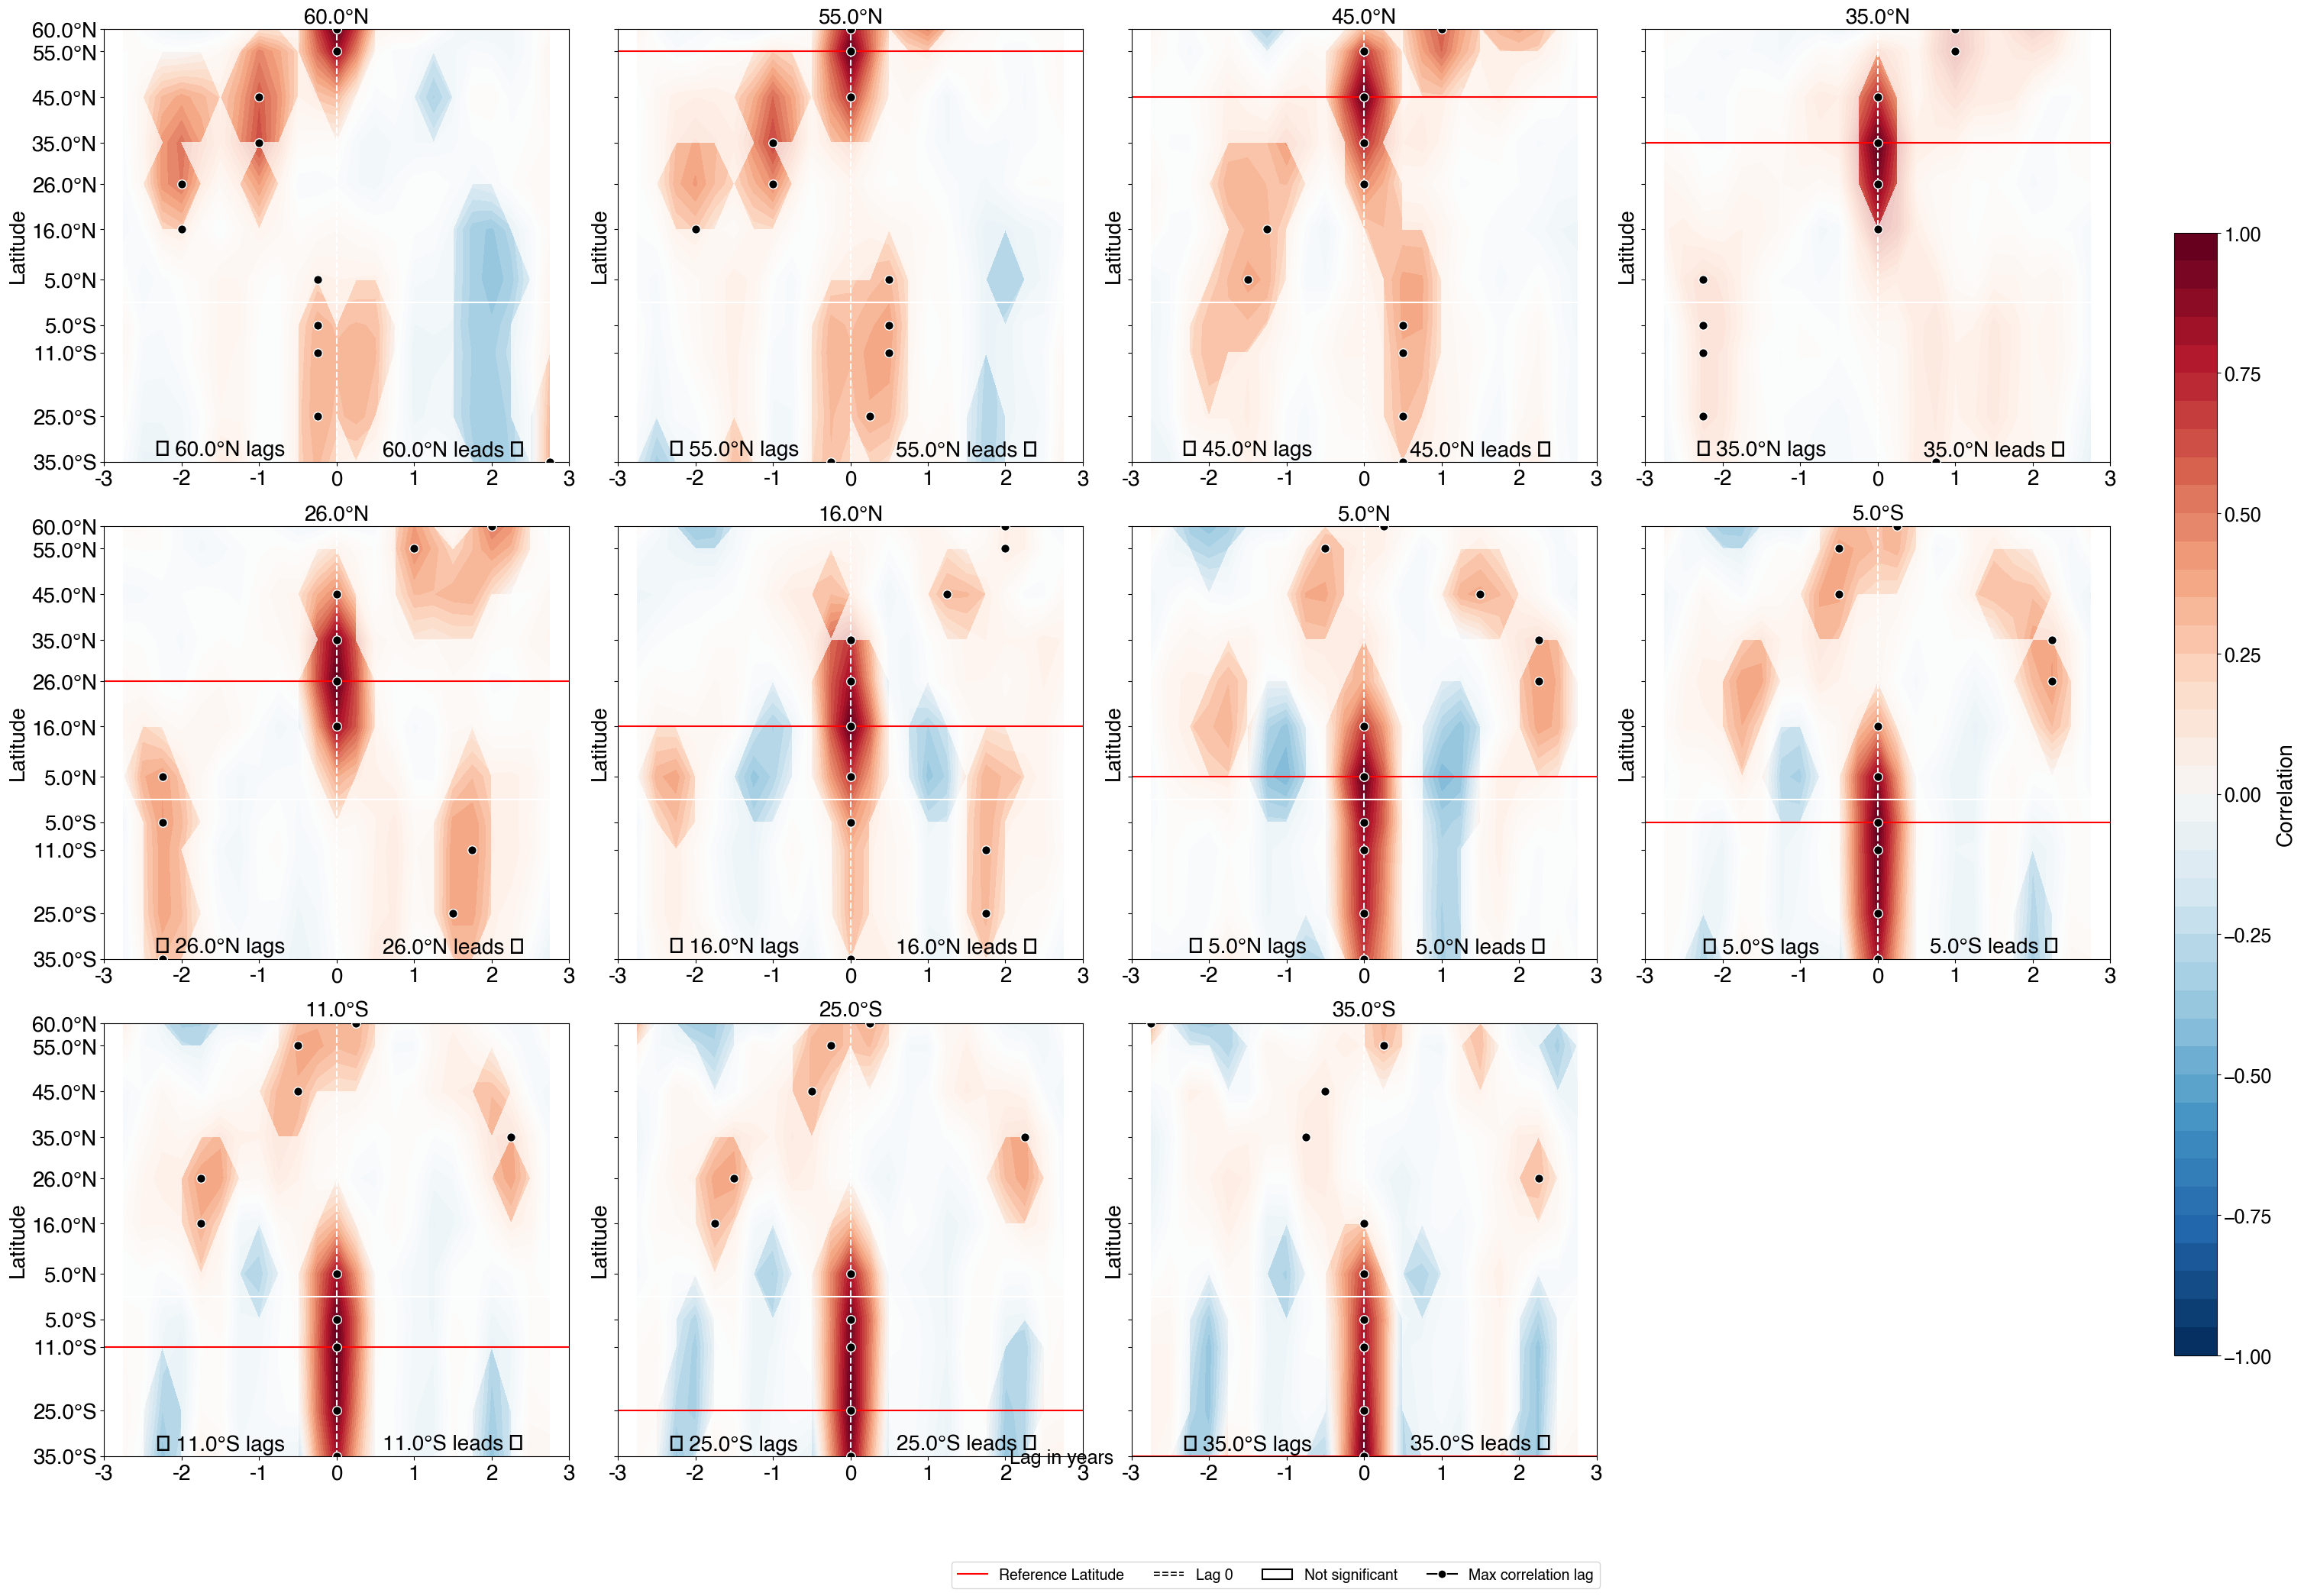

In [39]:
nlags = 12
all_lags = np.arange(-(nlags-1), nlags)
# all_lags = np.arange(0, nlags + 1)
lag_units = time_unit

_ = plot_all_leadlag(
    data=mht_filtered,
    lats=lats,
    lat_labels=lat_labels,
    #lats=[26],
    #lat_labels=["26.0°N"],
    all_lats=lats,
    all_lat_labels=lat_labels,
    nlags=nlags,
    all_lags=all_lags,
    ncols=4,
    significance=True,
    n_effs=n_effs_mht,
    cmap=cmap_corr,
    savefig=SAVING,
    savename="mht_leadlag_26N"
)

In [40]:
# nlags = 12
# all_lags = np.arange(-(nlags-1), nlags)
# # all_lags = np.arange(0, nlags + 1)
# lag_units = time_unit

# _ = plot_all_leadlag(
#     mht_filtered, lats, lat_labels,
#     nlags, all_lags, lag_units=lag_units,
#     significance=True, n_effs=n_effs_mht,
#     cmap=cmap_corr,
#     savefig=True
# )

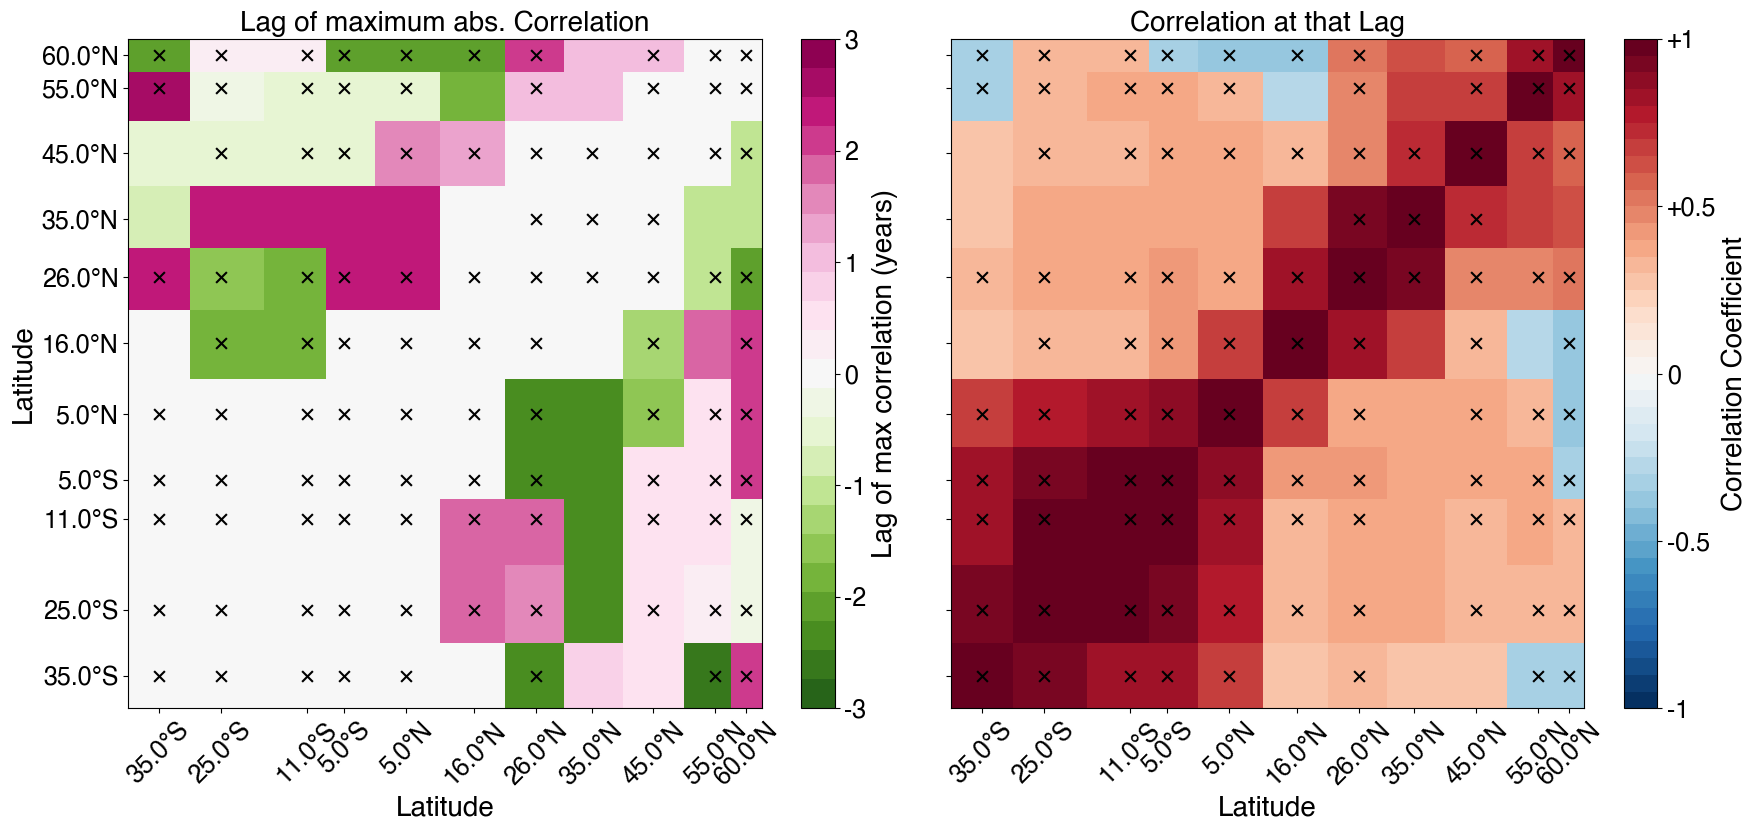

In [41]:


_ = plot_max_lag(mht_filtered,
                     lats, lat_labels, 
                     nlags, all_lags, lag_units=lag_units, 
                     significance=True, n_effs=n_effs_mht,
                     title="Lag of Maximum Correlation for MHT", 
                     cmap_corr=cmap_corr,
                     cmap_lag=cmap_maxlag,
                     savefig=True)

## lead lag only between block means

In [42]:
# n_effs_st = {key:val for key, val in n_effs_mht.items() if key in [35, 26, 16]}
# n_eff_st = min(n_effs_st.values())
# # print(n_eff_st)
# n_effs_sa = {key:val for key, val in n_effs_mht.items() if key in [-35, -25, -11, -5, 5]}
# n_eff_sa = min(n_effs_sa.values())
# # print(n_eff_sa)

# nlags=8
# all_lags = np.arange(-(nlags-1), nlags)

# _ = block_leadlag(st_data.mean(dim="lat"), sa_data.mean(dim="lat"),
#               periods,
#               nlags=nlags,
#               all_lags=all_lags,
#               n_eff_sa=n_eff_sa,
#               n_eff_st=n_eff_st
# )

## 3 year low pass filtered, what happens in the timeseries between 16 and 5°N on these scales? 

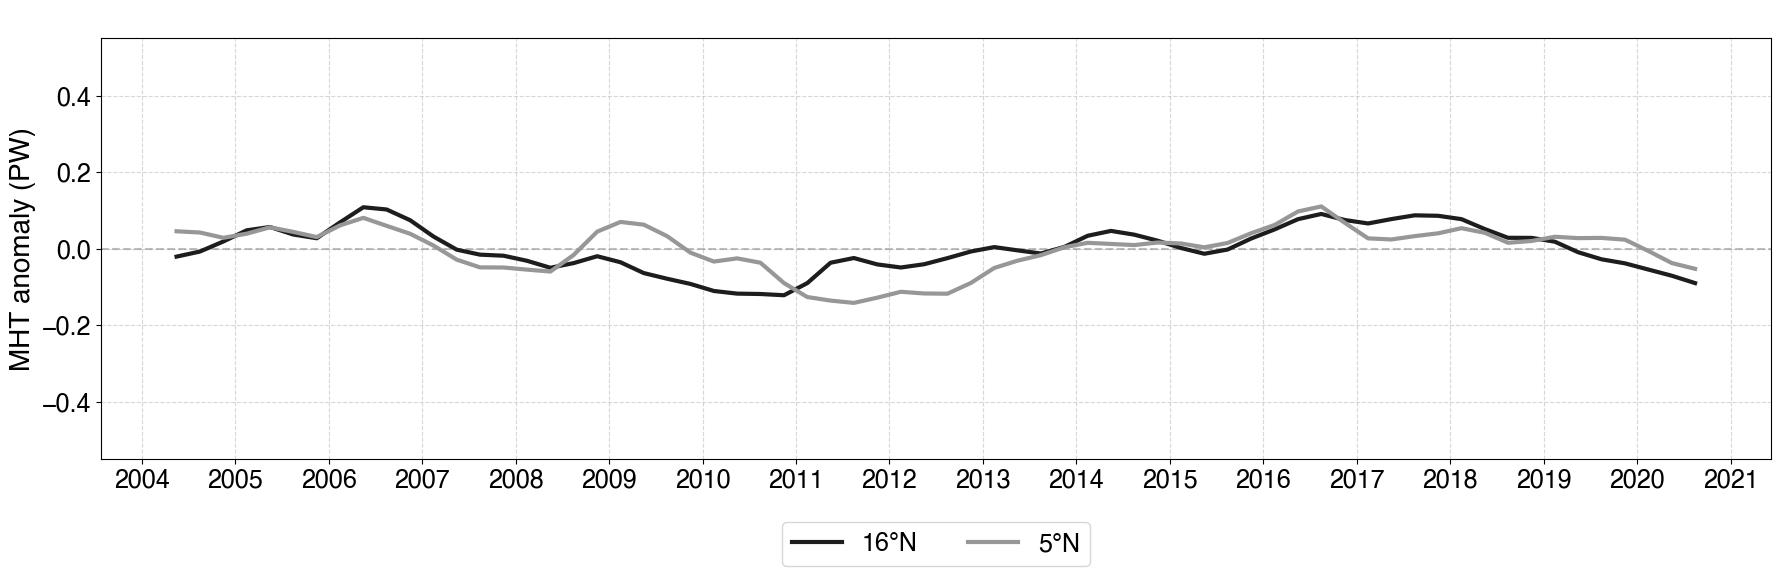

In [43]:

# for period_name, (t0, t1) in periods.items():
#     period_data = data_used.sel(time=slice(t0, t1))
lowpass_3yr_16n = mht_3yr_filter.isel(lat=idx_16)
lowpass_3yr_5n = mht_3yr_filter.isel(lat=idx_5)


fig, ax = plot_timeseries(
data={"16°N" : lowpass_3yr_16n,
      "5°N": lowpass_3yr_5n},
lats=[0],
all_lats=[0],
labels=["16°N", "5°N"],
title="",
cmap=cmap_cropped_lats,
label=f"",
savefig=True,
savelabel=f"MHT_16N5N_total_3yrfilter",
grid=True,
linestyles={"16°N" : "-",
      "5°N": "-"},
savefolder="timeseries/16_5N",
ylim=(-0.55, 0.55)
)

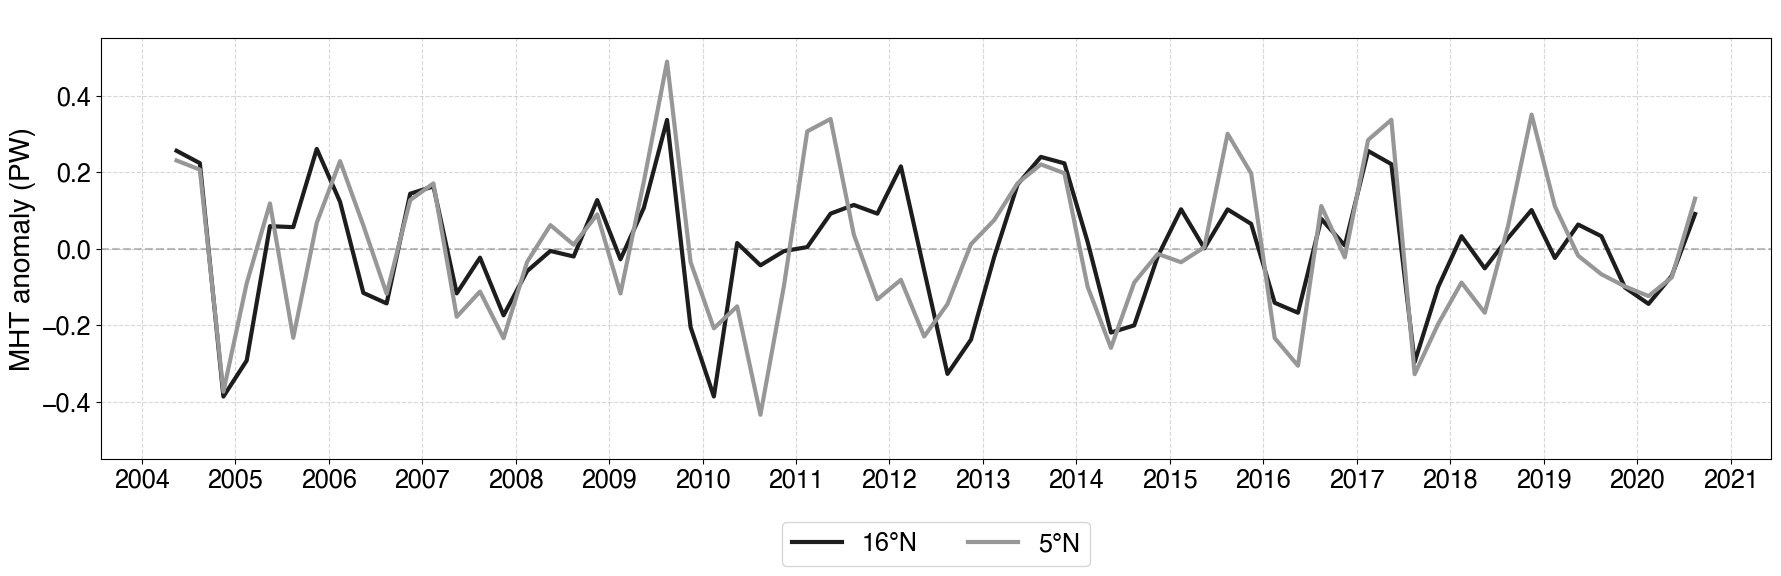

In [44]:
detrended_16N = data_used.isel(lat=idx_16)
detrended_5N = data_used.isel(lat=idx_5)


fig, ax = plot_timeseries(
data={"16°N" : detrended_16N-lowpass_3yr_16n,
      "5°N": detrended_5N-lowpass_3yr_5n},
lats=[0],
all_lats=[0],
labels=["16°N", "5°N"],
title="",
cmap=cmap_cropped_lats,
label=f"",
savefig=True,
savelabel=f"MHT_16N5N_total_difference",
grid=True,
linestyles={"16°N" : "-",
      "5°N": "-"},
savefolder="timeseries/16_5N",
ylim=(-0.55, 0.55)
)